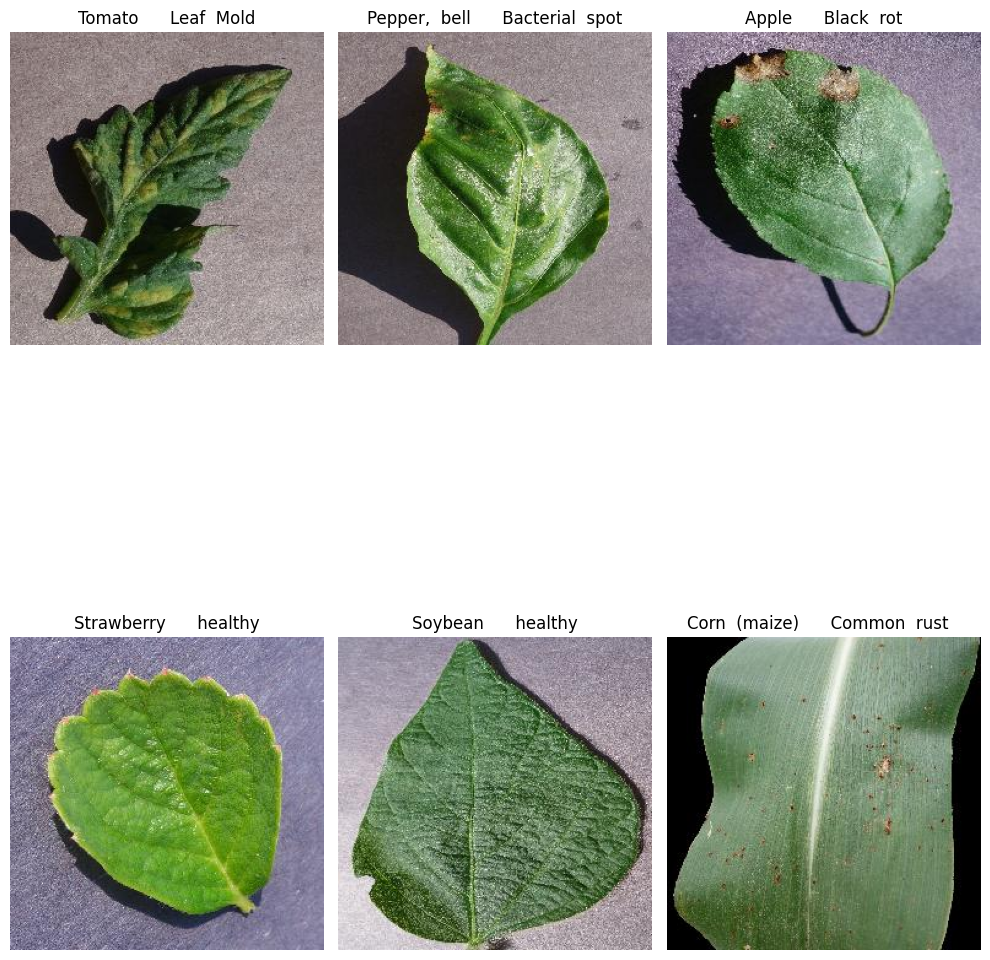

In [1]:
import os
import random
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# Setup Paths
load_dotenv()
data_path = os.getenv("RAW_DATA_PATH")
categories = [d for d in os.listdir(data_path) if os.path.join(data_path,d)]

# Picking 6 random categories to preview
simple_cats = random.sample(categories,6)

plt.figure(figsize = (10,15))
for i, cat in enumerate(simple_cats):
    cat_dir = os.path.join(data_path,cat)
    image_name = random.choice(os.listdir(cat_dir))
    image_path = os.path.join(cat_dir,image_name)

    image = Image.open(image_path)
    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(cat.replace("_", "  "))
    plt.axis('off')


plt.tight_layout()
plt.show()

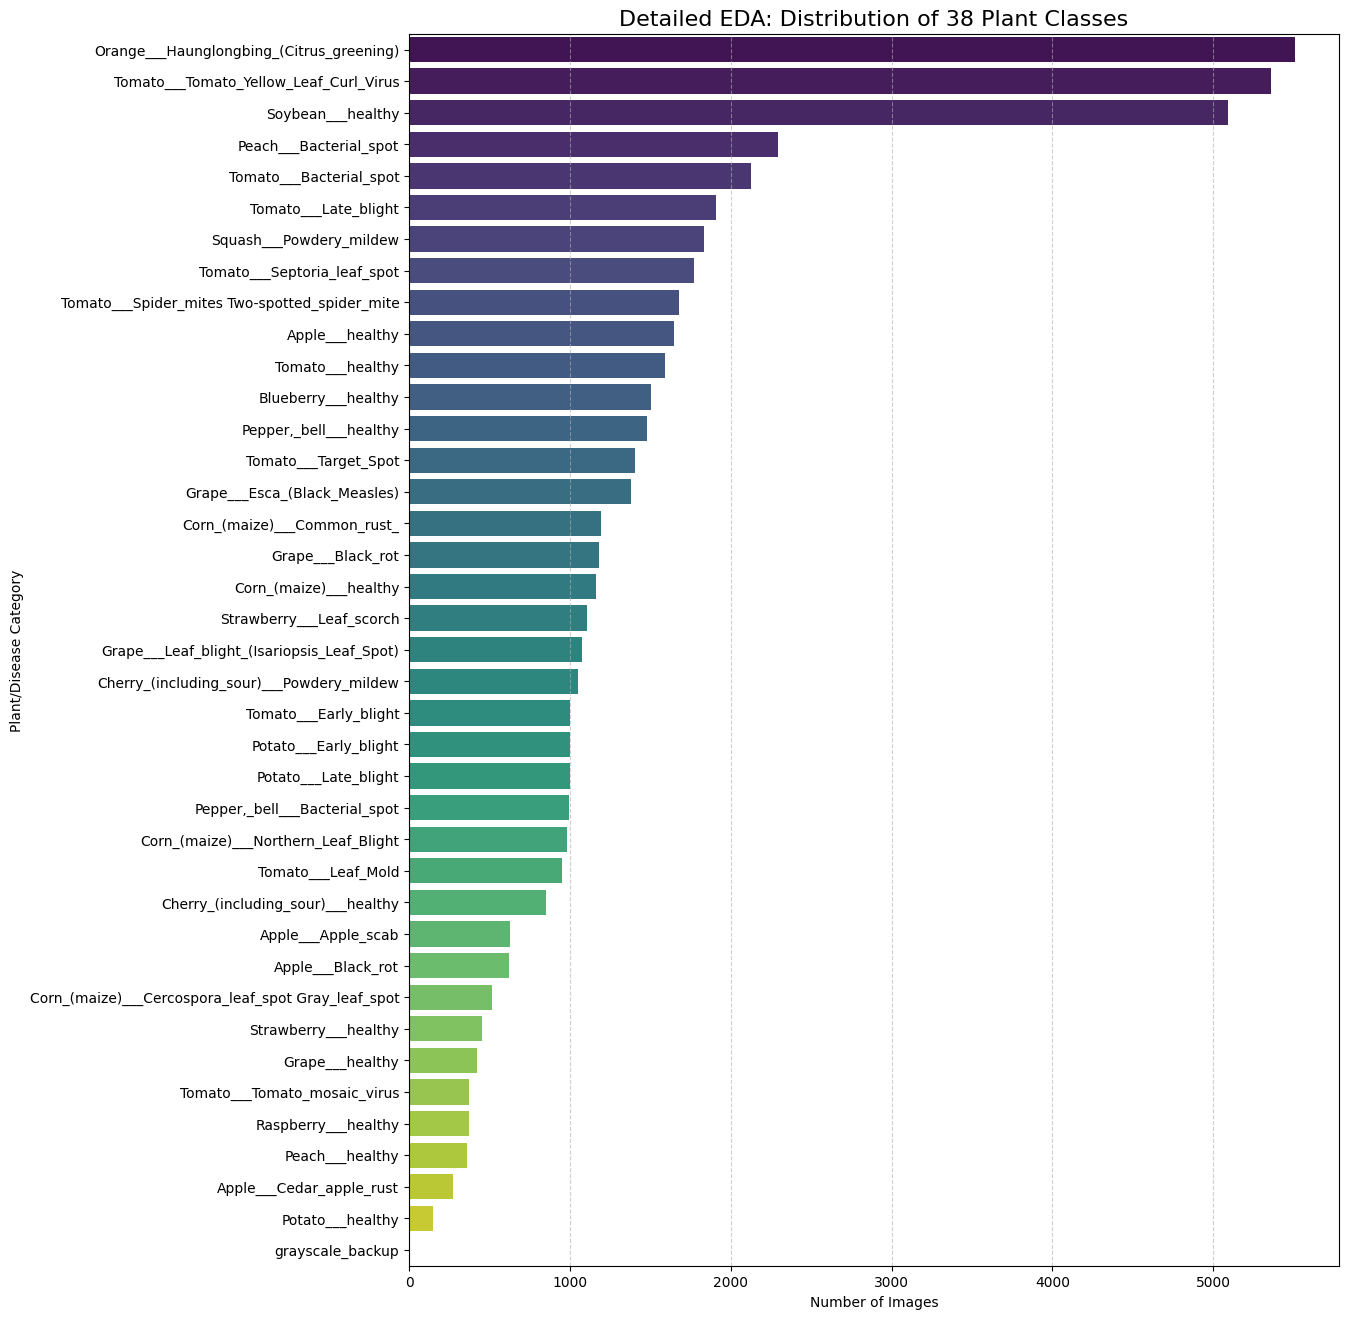

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. First, we must generate the data from your folders
stats = []
for cat in categories:
    n_images = len(os.listdir(os.path.join(data_path, cat)))
    stats.append({"Class": cat, "Count": n_images})

# 2. Create the DataFrame using the 'pd.' prefix
df = pd.DataFrame(stats)
df_sorted = df.sort_values("Count", ascending=False)

# 3. Create the Detailed Bar Chart
plt.figure(figsize=(12, 16)) 
sns.barplot(x="Count", y="Class", data=df_sorted, palette="viridis",hue ="Class",legend=False)

plt.title("Detailed EDA: Distribution of 38 Plant Classes", fontsize=16)
plt.xlabel("Number of Images")
plt.ylabel("Plant/Disease Category")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [3]:
# 1. Print a clean text-based summary of the counts
print("--- Dataset Bin Counts (Text Summary) ---")
# This iterates through your sorted data and prints the name + count
for index, row in df_sorted.iterrows():
    print(f"Class: {row['Class']:<50} | Images: {row['Count']}")

# 2. Add a summary of the total and imbalance check
print("-" * 70)
print(f"Total Images in Dataset: {df_sorted['Count'].sum()}")
print(f"Max Images in a Class:   {df_sorted['Count'].max()}")
print(f"Min Images in a Class:   {df_sorted['Count'].min()}")

--- Dataset Bin Counts (Text Summary) ---
Class: Orange___Haunglongbing_(Citrus_greening)           | Images: 5507
Class: Tomato___Tomato_Yellow_Leaf_Curl_Virus             | Images: 5357
Class: Soybean___healthy                                  | Images: 5090
Class: Peach___Bacterial_spot                             | Images: 2297
Class: Tomato___Bacterial_spot                            | Images: 2127
Class: Tomato___Late_blight                               | Images: 1909
Class: Squash___Powdery_mildew                            | Images: 1835
Class: Tomato___Septoria_leaf_spot                        | Images: 1771
Class: Tomato___Spider_mites Two-spotted_spider_mite      | Images: 1676
Class: Apple___healthy                                    | Images: 1645
Class: Tomato___healthy                                   | Images: 1591
Class: Blueberry___healthy                                | Images: 1502
Class: Pepper,_bell___healthy                             | Images: 1478
Class: To

2026-02-15 23:41:10.272121: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 23:41:22.952835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 23:42:06.202058: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/shahzad/Downloads/AI/ImadVirtual/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Testing on: Apple___Black_rot --> 307abcdd-96f7-404a-9032-2ce8de2fde48___JR_FrgE.S 8781.JPG


2026-02-15 23:42:18.750941: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


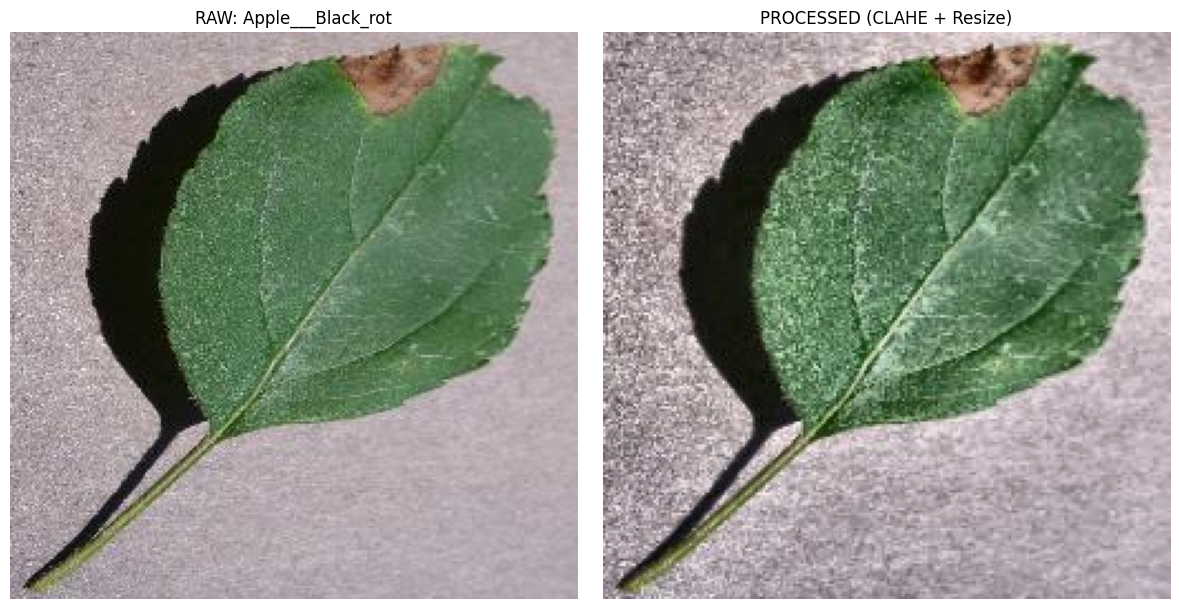


Original shape: (256, 256, 3)
Processed shape: (224, 224, 3)
Original pixel range: 0 to 255
Processed pixel range: 0.000 to 1.000


In [4]:
import random
import matplotlib.pyplot as plt
import os
import sys
import cv2
import numpy as np

# Setup the modules folder
sys.path.append(os.path.abspath(".."))
from modules.preprocessing import image_preprocessing

# Automatically find a random image
base_path = os.path.abspath("..")
raw_dir = os.path.join(base_path, "data/raw/raw/color")

# Pick a random category folder
all_category = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]
random_cat = random.choice(all_category)
cat_path = os.path.join(raw_dir, random_cat)

# Pick a random image from that folder
# Support multiple image formats, not just JPG
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.JPG', '.JPEG', '.PNG')
valid_images = [i for i in os.listdir(cat_path) if i.lower().endswith(image_extensions)]

if not valid_images:
    print(f"No images found in {cat_path}")
else:
    random_image_cat = random.choice(valid_images)
    img_path = os.path.join(cat_path, random_image_cat)

    print(f"Testing on: {random_cat} --> {random_image_cat}")

    # Process the image
    original = cv2.imread(img_path)
    
    if original is None:
        print(f"Error: Could not load image at {img_path}")
    else:
        original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Get processed image
        processed_img, _ = image_preprocessing(original, "test_label")

        if processed_img is not None:
            # FIXED LINE: Convert tensor to numpy
            processed_plot = processed_img.numpy()  # This is the only change!
            
            # Display the comparison
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            
            # Original image
            axes[0].imshow(original)
            axes[0].set_title(f"RAW: {random_cat}")
            axes[0].axis('off')
            
            # Processed image (CLAHE applied)
            axes[1].imshow(processed_plot)
            axes[1].set_title("PROCESSED (CLAHE + Resize)")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()
            
            # Print stats for verification
            print(f"\nOriginal shape: {original.shape}")
            print(f"Processed shape: {processed_plot.shape}")
            print(f"Original pixel range: {original.min()} to {original.max()}")
            print(f"Processed pixel range: {processed_plot.min():.3f} to {processed_plot.max():.3f}")
            
            # Additional check for grayscale handling
            if len(original.shape) == 2 or original.shape[2] == 1:
                print("️Original image was grayscale (converted to RGB)")

In [5]:
"""
# Calculate Class Weights for Imbalanced Dataset
Lets determine class weights for both models
"""

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Load your data
data = np.load("/home/shahzad/Downloads/AI/DL/Transfer Learning/PlantVillage/data/processed/efficientnetv2_features.npz")
y = np.argmax(data['labels'], axis=1)  # Convert one-hot to class indices

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Convert to dictionary and save
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# Save to file for later use
np.save(
    "/home/shahzad/Downloads/AI/DL/Transfer Learning/PlantVillage/data/processed/class_weights.npy",
    class_weights
)

print("Class Weights Calculated and Saved:")
for class_idx, weight in class_weight_dict.items():
    class_name = data['class_names'][class_idx]
    count = np.sum(y == class_idx)
    print(f"{class_name:40} | Images: {count:4} | Weight: {weight:.2f}")

Class Weights Calculated and Saved:
Apple___Apple_scab                       | Images:  630 | Weight: 2.27
Apple___Black_rot                        | Images:  621 | Weight: 2.30
Apple___Cedar_apple_rust                 | Images:  275 | Weight: 5.20
Apple___healthy                          | Images: 1645 | Weight: 0.87
Blueberry___healthy                      | Images: 1502 | Weight: 0.95
Cherry_(including_sour)___Powdery_mildew | Images: 1052 | Weight: 1.36
Cherry_(including_sour)___healthy        | Images:  854 | Weight: 1.67
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | Images:  513 | Weight: 2.79
Corn_(maize)___Common_rust_              | Images: 1192 | Weight: 1.20
Corn_(maize)___Northern_Leaf_Blight      | Images:  985 | Weight: 1.45
Corn_(maize)___healthy                   | Images: 1162 | Weight: 1.23
Grape___Black_rot                        | Images: 1180 | Weight: 1.21
Grape___Esca_(Black_Measles)             | Images: 1383 | Weight: 1.03
Grape___Leaf_blight_(Isariopsis